# Anatomy of the Perseids
### Why August, why the 12th–13th, and why it looks the way it does from Akçay

This notebook is a companion to the Astropy prototype notebook — that one answered "what time should I look up." This one answers the bigger *why* questions behind the shower itself, in three layers, zooming in from the whole solar system down to one specific night from one specific beach.

1. **Why August at all?** — an orbital-scale diagram of Earth crossing Comet Swift-Tuttle's debris trail
2. **Why the 12th–13th specifically?** — the shower's activity curve (ZHR) across its ~5-week active window
3. **What does that mean for you?** — reconnecting to the radiant altitude curve for Akçay/Balıkesir

Plus a bonus animation at the end showing *why a radiant looks like a single point* in the first place.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

plt.rcParams['figure.facecolor'] = '#0B1120'
plt.rcParams['axes.facecolor'] = '#0B1120'
plt.rcParams['text.color'] = '#F4EFE6'
plt.rcParams['axes.labelcolor'] = '#F4EFE6'
plt.rcParams['xtick.color'] = '#8B96B8'
plt.rcParams['ytick.color'] = '#8B96B8'
plt.rcParams['axes.edgecolor'] = '#2A3554'
plt.rcParams['grid.color'] = '#2A3554'

AMBER = '#E8A54B'
PEAK  = '#C4527A'
STAR  = '#F4EFE6'
DIM   = '#8B96B8'
PANEL = '#1B2740'

print("Ready.")

Ready.


## Part 1 — Why August? A comet's debris trail

The Perseids come from **Comet 109P/Swift-Tuttle**, discovered in 1862. It's a big one — about 26 km across — on a highly elongated orbit that swings from just inside Earth's orbit (perihelion ≈ 0.96 AU) out past Pluto (aphelion ≈ 51 AU), taking about **133 years** per lap. Every pass near the Sun, it sheds a stream of dust and gravel that spreads out along its orbital path over centuries.

That debris trail is essentially fixed in space (it drifts very slowly over centuries, but for our purposes it's stationary). Earth's orbit is also fixed. **Earth crosses this particular trail at the same point in its own orbit every year** — and since Earth's position in its orbit maps directly to the calendar date, that crossing always happens in mid-August. That's the whole reason "Perseids = August" is a fixed appointment rather than something that shifts year to year.

Let's draw it: Earth's near-circular orbit, Swift-Tuttle's long, thin orbit, and the point where they intersect.

/tmp/ipykernel_346/3271417748.py:23: RuntimeWarning: invalid value encountered in log1p
  r_display = np.where(r_comet > 3, 3 + np.log1p(r_comet-3)*0.9, r_comet)


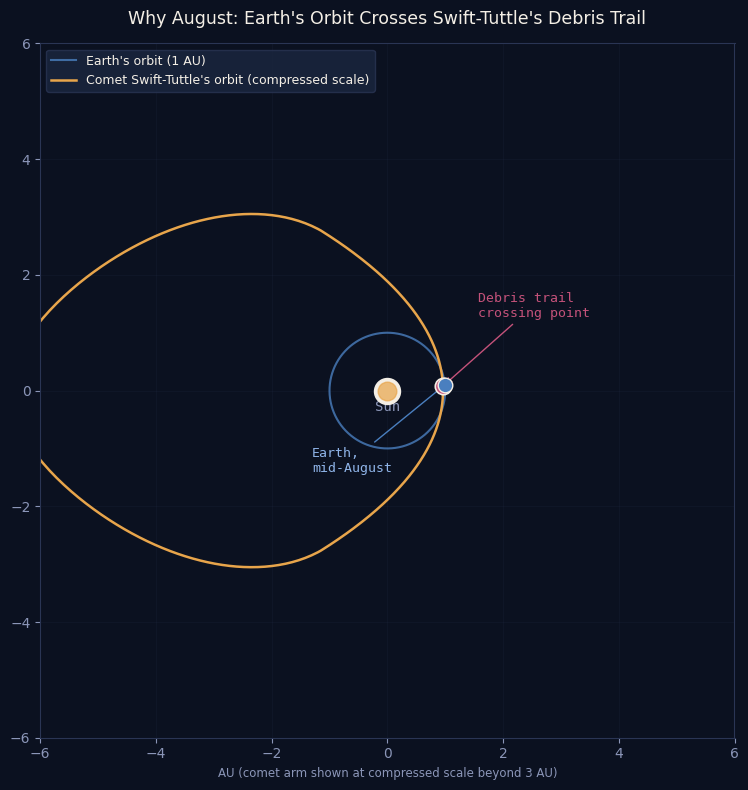

In [2]:
fig, ax = plt.subplots(figsize=(8, 8))

# --- Sun ---
ax.scatter([0], [0], color='#F4EFE6', s=350, zorder=5)
ax.scatter([0], [0], color='#E8A54B', s=180, zorder=6, alpha=0.7)
ax.text(0, -0.35, 'Sun', color=DIM, ha='center', fontsize=10, family='monospace')

# --- Earth's orbit (near-circular, 1 AU) ---
theta = np.linspace(0, 2*np.pi, 400)
earth_r = 1.0
ax.plot(earth_r*np.cos(theta), earth_r*np.sin(theta), color='#4A7FBF', linewidth=1.5, alpha=0.8, label="Earth's orbit (1 AU)")

# --- Swift-Tuttle's orbit (illustrative ellipse, real perihelion/aphelion, flattened to 2D) ---
# perihelion ~0.96 AU, aphelion ~51 AU -> a ~ 26 AU, e ~ 0.963
a_comet, e_comet = 26.0, 0.963
b_comet = a_comet * np.sqrt(1 - e_comet**2)
c_comet = a_comet * e_comet  # focus offset
# scale down aphelion for display purposes (log-ish compression) so the plot stays readable
# we keep the near-Earth crossing geometrically correct, but compress far end visually
comet_theta = np.linspace(0, 2*np.pi, 500)
r_comet = a_comet*(1-e_comet**2) / (1 + e_comet*np.cos(comet_theta))
# display-scale compression for the far aphelion arm only (visual clarity, not to true scale)
r_display = np.where(r_comet > 3, 3 + np.log1p(r_comet-3)*0.9, r_comet)
comet_x = r_display*np.cos(comet_theta)
comet_y = r_display*np.sin(comet_theta)
ax.plot(comet_x, comet_y, color=AMBER, linewidth=1.8, label="Comet Swift-Tuttle's orbit (compressed scale)")

# --- Intersection / debris trail crossing point (near perihelion side) ---
cross_theta = 0.08  # near perihelion, close to Earth's orbit
cross_r = a_comet*(1-e_comet**2) / (1 + e_comet*np.cos(cross_theta))
cross_x, cross_y = cross_r*np.cos(cross_theta), cross_r*np.sin(cross_theta)
ax.scatter([cross_x], [cross_y], color=PEAK, s=140, zorder=7, edgecolor=STAR, linewidth=1.2)
ax.annotate('Debris trail\ncrossing point', (cross_x, cross_y), xytext=(cross_x+0.6, cross_y+1.2),
            color=PEAK, fontsize=9.5, family='monospace',
            arrowprops=dict(arrowstyle='->', color=PEAK, lw=1))

# --- Earth's mid-August position ---
earth_theta = cross_theta + 0.02
ex, ey = earth_r*np.cos(earth_theta), earth_r*np.sin(earth_theta)
ax.scatter([ex], [ey], color='#4A7FBF', s=110, zorder=7, edgecolor=STAR, linewidth=1)
ax.annotate('Earth,\nmid-August', (ex, ey), xytext=(ex-2.3, ey-1.5),
            color='#8FB4E8', fontsize=9.5, family='monospace',
            arrowprops=dict(arrowstyle='->', color='#4A7FBF', lw=1))

ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)
ax.set_aspect('equal')
ax.set_title("Why August: Earth's Orbit Crosses Swift-Tuttle's Debris Trail",
              color=STAR, fontsize=12.5, pad=14)
ax.legend(loc='upper left', facecolor=PANEL, edgecolor='#2A3554', labelcolor=STAR, fontsize=9)
ax.grid(alpha=0.15)
ax.set_xlabel('AU (comet arm shown at compressed scale beyond 3 AU)', color=DIM, fontsize=8.5)

plt.tight_layout()
plt.savefig('orbit_diagram.png', dpi=130, facecolor=fig.get_facecolor())
plt.show()

**Reading the diagram:** the amber curve is compressed past 3 AU purely so the whole orbit fits on one page — in reality Swift-Tuttle travels almost to the outer solar system before swinging back. The important part is the crossing point (pink) sitting right where Earth's blue orbit passes by every mid-August. Earth doesn't "aim" for the trail — it's simply always there on this date, every year, like a train passing the same signal post on the same lap.

## Part 2 — Why the 12th–13th specifically?

Crossing the trail doesn't mean instant fireworks — the debris isn't a thin wire, it's a wide, uneven band, denser toward its center. As Earth cuts through, the meteor rate (measured as **ZHR**, Zenithal Hourly Rate — meteors per hour under ideal dark-sky conditions with the radiant overhead) rises slowly as we enter the outskirts of the trail, climbs faster near the middle, and falls off again as we exit. The Perseids are active for roughly five weeks (mid-July through late August), but the *dense core* of the trail is narrow — which is why there's a sharp, short peak around August 12–13 rather than a flat five-week plateau.

Let's sketch that activity curve. The exact shape is a well-known general characteristic of the shower — a slow rise, a sharp peak, and a slightly faster decline — so we'll build an illustrative curve with that shape rather than claiming exact historical ZHR values for every date.

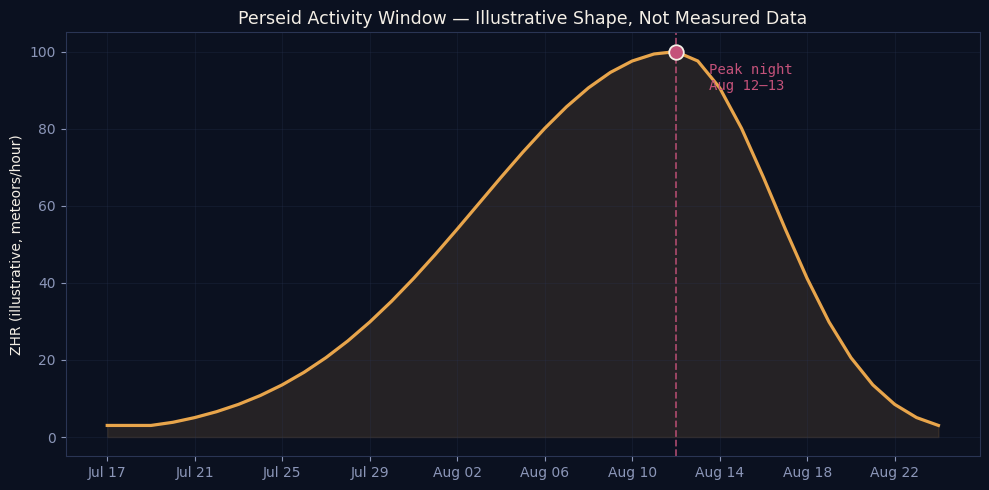

In [3]:
from datetime import date

start = date(2026, 7, 17)
peak  = date(2026, 8, 12)
end   = date(2026, 8, 24)

days = np.arange((start - start).days, (end - start).days + 1)
dates = [start + __import__('datetime').timedelta(days=int(d)) for d in days]
peak_day = (peak - start).days
total_days = (end - start).days

# Illustrative asymmetric activity curve: slower rise, sharp peak, faster decline
zhr = np.zeros_like(days, dtype=float)
rise_days = days[days <= peak_day]
fall_days = days[days > peak_day]

rise_sigma = 9.0   # slow build-up
fall_sigma = 4.5   # faster drop-off

zhr_rise = 100 * np.exp(-0.5 * ((rise_days - peak_day) / rise_sigma) ** 2)
zhr_fall = 100 * np.exp(-0.5 * ((fall_days - peak_day) / fall_sigma) ** 2)
zhr = np.concatenate([zhr_rise, zhr_fall])
zhr = np.maximum(zhr, 3)  # small background sporadic rate floor

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(days, zhr, color=AMBER, linewidth=2.3)
ax.fill_between(days, 0, zhr, color=AMBER, alpha=0.12)

ax.axvline(peak_day, color=PEAK, linewidth=1.3, linestyle='--', alpha=0.8)
ax.scatter([peak_day], [100], color=PEAK, s=110, zorder=5, edgecolor=STAR, linewidth=1.3)
ax.annotate('Peak night\nAug 12–13', (peak_day, 100), xytext=(peak_day+1.5, 90),
            color=PEAK, fontsize=10, family='monospace')

tick_idx = list(range(0, total_days+1, 4))
ax.set_xticks([days[i] for i in tick_idx])
ax.set_xticklabels([dates[i].strftime('%b %d') for i in tick_idx], rotation=0)

ax.set_ylabel('ZHR (illustrative, meteors/hour)')
ax.set_title('Perseid Activity Window — Illustrative Shape, Not Measured Data', color=STAR, fontsize=12.5)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig('zhr_curve.png', dpi=130, facecolor=fig.get_facecolor())
plt.show()

**Note on this plot:** the curve's *shape* (slow rise, sharp peak, quicker decline) reflects the shower's well-known general behavior, but the exact numbers are illustrative, not pulled from a live IMO dataset — think of it as a diagram, not a measurement. If you want the real historical ZHR profile for the blog post, that would need pulling IMO's published visual/video observation data directly, which is a good "Part 2" follow-up.

## Part 3 — Bringing it home: from the whole trail to your beach

Zooming out told us *why August*. The activity curve told us *why the 12th–13th*. Now we zoom all the way back in to the piece the Astropy prototype already solved: given that this is the peak night, when does the radiant actually climb highest **over Akçay/Balıkesir**? Let's pull that calculation back in for a quick side-by-side.

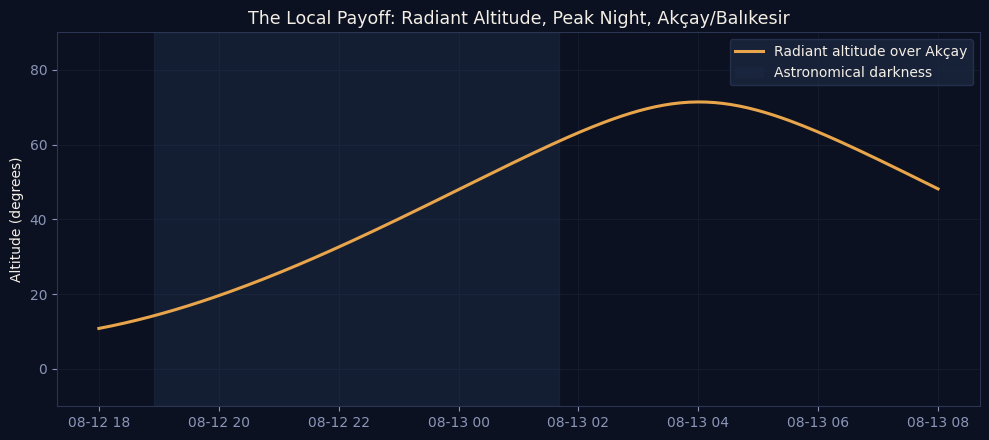

Solar-system scale  -> shower exists because Earth crosses Swift-Tuttle's trail every mid-August
Trail-density scale  -> that crossing has a sharp core, giving a peak around Aug 12-13
Observer scale       -> from Akçay, the radiant itself climbs highest in the pre-dawn hours of that peak night


In [4]:
from astropy import units as u
from astropy.time import Time
from astropy.coordinates import EarthLocation, SkyCoord, AltAz, get_sun

akcay = EarthLocation(lat=39.5822*u.deg, lon=26.9186*u.deg, height=10*u.m)
radiant = SkyCoord(ra=48.2*u.deg, dec=58.1*u.deg, frame='icrs')

night_start = Time("2026-08-12 18:00:00", scale="utc")
night_end   = Time("2026-08-13 08:00:00", scale="utc")
times = night_start + (night_end - night_start) * np.linspace(0, 1, 200)

altaz_frame = AltAz(obstime=times, location=akcay)
radiant_alt = radiant.transform_to(altaz_frame).alt.deg
sun_alt = get_sun(times).transform_to(altaz_frame).alt.deg
dark_mask = sun_alt < -18

fig, ax = plt.subplots(figsize=(10, 4.5))
times_dt = times.datetime
ax.plot(times_dt, radiant_alt, color=AMBER, linewidth=2.2, label='Radiant altitude over Akçay')
ax.fill_between(times_dt, -10, 90, where=dark_mask, color=PANEL, alpha=0.6, label='Astronomical darkness')
ax.set_ylim(-10, 90)
ax.set_title('The Local Payoff: Radiant Altitude, Peak Night, Akçay/Balıkesir', color=STAR, fontsize=12.5)
ax.set_ylabel('Altitude (degrees)')
ax.legend(facecolor=PANEL, edgecolor='#2A3554', labelcolor=STAR)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig('local_payoff.png', dpi=130, facecolor=fig.get_facecolor())
plt.show()

print("Solar-system scale  -> shower exists because Earth crosses Swift-Tuttle's trail every mid-August")
print("Trail-density scale  -> that crossing has a sharp core, giving a peak around Aug 12-13")
print("Observer scale       -> from Akçay, the radiant itself climbs highest in the pre-dawn hours of that peak night")

### Swapping in real data — Global Meteor Network

The curve above is illustrative. IMO's own live ZHR feed requires a free membership + API key to query, but the **Global Meteor Network** (the same open project behind the RMS camera setup planned for later) publishes real, camera-derived flux/ZHR plots for every active shower, updated daily, under a CC BY 4.0 license — no login needed.

It doesn't expose raw numbers via a public JSON/CSV endpoint, only ready-made plot images, so this cell fetches the actual Perseid 2026 plot (and a 2024–2026 multi-year comparison) straight from their servers and embeds it here, with proper attribution.

> **Note:** this cell needs outbound internet access to `globalmeteornetwork.org`. It could not be executed inside the sandbox this notebook was built in (network allowlist), so the cell below ran with that restriction in place — rerun it in an environment with normal internet access to pull the live images.

Saved: PER 2026 flux/ZHR -> gmn_data/flux_PER_sol=123.00-147.00_year_2026.png
Saved: PER 2024-2026 multi-year comparison -> gmn_data/flux_PER_sol=123.00-147.00_all_years.png


### PER 2026 flux/ZHR

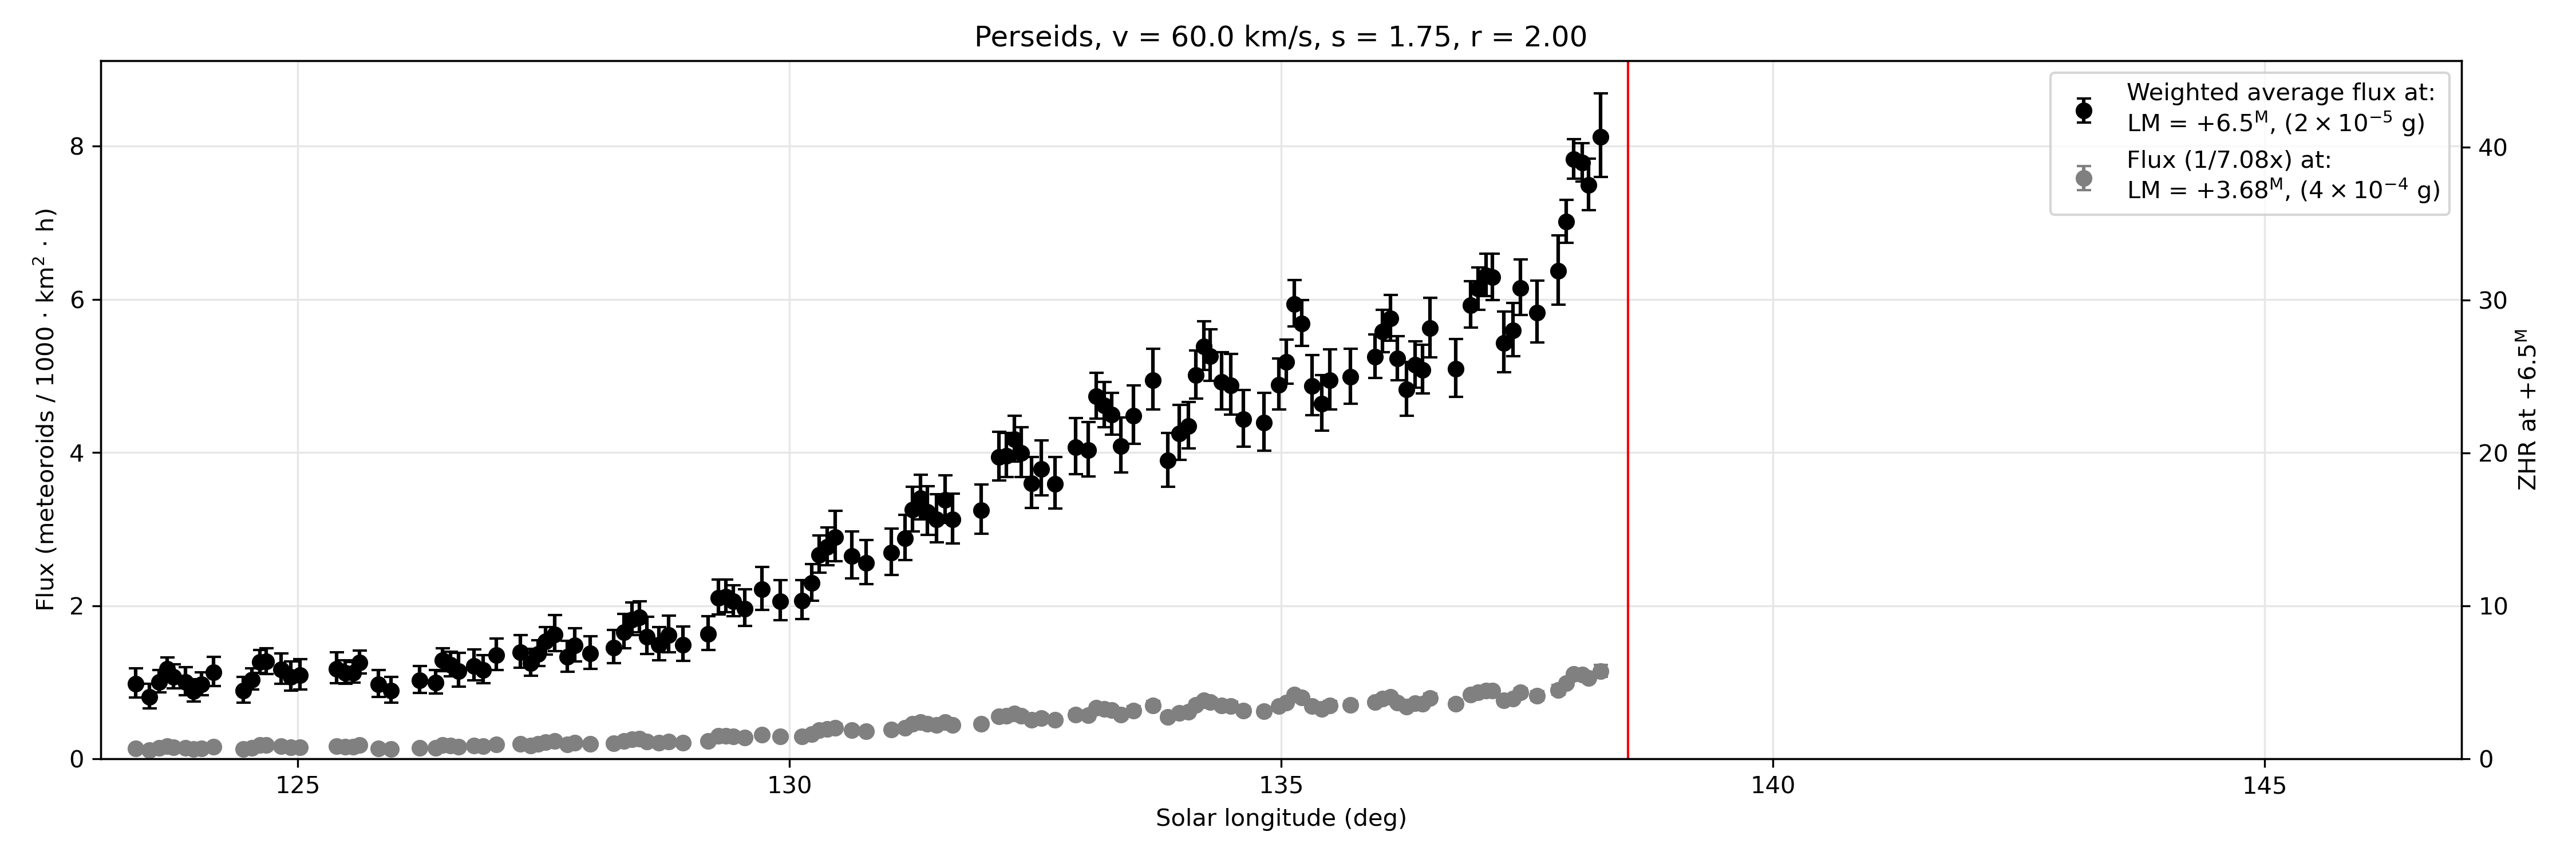

### PER 2024-2026 multi-year comparison

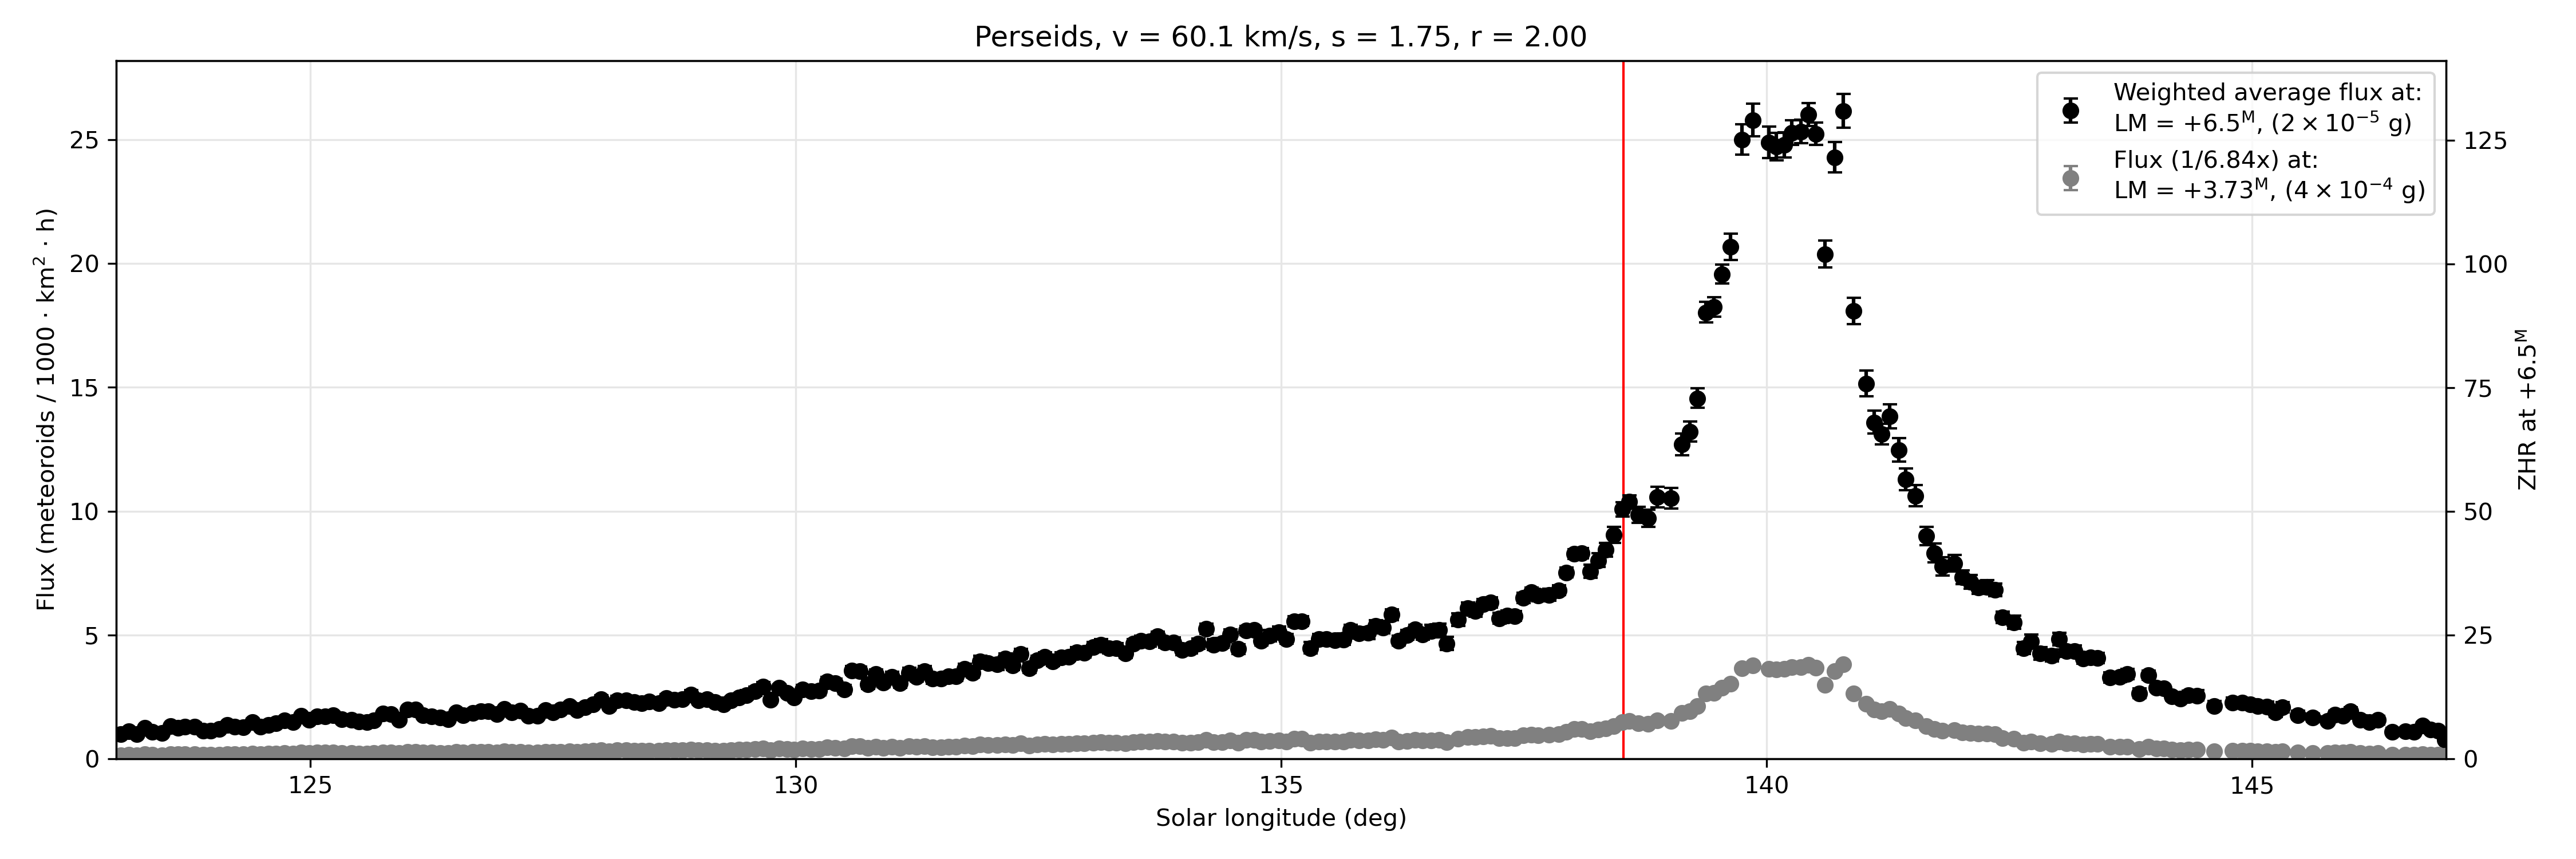

**Data source:** Global Meteor Network (GMN), released under [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/). GMN data collection is supported in part by the NASA Meteoroid Environment Office under cooperative agreement 80NSSC21M0073 with the Western Meteor Physics Group.

If used in a publication, cite:
- Vida, D., et al. (2021). *The Global Meteor Network — Methodology and first results.* MNRAS, 506(4), 5046-5074.
- Vida, D., et al. (2022). *Computing optical meteor flux using global meteor network data.* MNRAS, 515(2), 2322-2339.

In [5]:
import os
import requests
from IPython.display import Image, display, Markdown

OUTPUT_DIR = "gmn_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Solar-longitude window for the Perseids (GMN operational shower table:
# sol begin=123.00, max=140.40, end=147.00), current year.
PLOTS = {
    "PER 2026 flux/ZHR": (
        "https://globalmeteornetwork.org/flux/plots/"
        "flux_PER_sol=123.00-147.00_year_2026.png"
    ),
    "PER 2024-2026 multi-year comparison": (
        "https://globalmeteornetwork.org/flux/plots/"
        "flux_PER_sol=123.00-147.00_all_years.png"
    ),
}

downloaded = {}

for label, url in PLOTS.items():
    filename = os.path.join(OUTPUT_DIR, url.split("/")[-1])
    try:
        resp = requests.get(url, timeout=20)
        resp.raise_for_status()
        with open(filename, "wb") as f:
            f.write(resp.content)
        downloaded[label] = filename
        print(f"Saved: {label} -> {filename}")
    except requests.RequestException as e:
        print(f"Could not fetch '{label}': {e}")

for label, path in downloaded.items():
    display(Markdown(f"### {label}"))
    display(Image(filename=path))

display(Markdown(
    "**Data source:** Global Meteor Network (GMN), released under "
    "[CC BY 4.0](https://creativecommons.org/licenses/by/4.0/). "
    "GMN data collection is supported in part by the NASA Meteoroid "
    "Environment Office under cooperative agreement 80NSSC21M0073 with "
    "the Western Meteor Physics Group.\n\n"
    "If used in a publication, cite:\n"
    "- Vida, D., et al. (2021). *The Global Meteor Network — Methodology "
    "and first results.* MNRAS, 506(4), 5046-5074.\n"
    "- Vida, D., et al. (2022). *Computing optical meteor flux using "
    "global meteor network data.* MNRAS, 515(2), 2322-2339."
))

**About the 403 above:** this sandbox's outbound network only allows a fixed list of domains (package registries, GitHub, etc.) and `globalmeteornetwork.org` isn't on it, so the request never reaches GMN's servers at all — the 403 is coming from the sandbox's own egress proxy blocking the domain, not from GMN rejecting the request. Run this cell in a normal Python environment (your laptop, Colab, etc.) and it should fetch the real images without any changes.

## Bonus — why a radiant looks like a single point

One more thing worth *seeing* rather than just being told: the perspective effect that makes scattered meteors appear to radiate from one spot. Below, a small animation: particles travel on parallel paths through space (left), but projected onto your sky (right), they appear to diverge from a single point — the same way railway tracks appear to meet at the horizon.

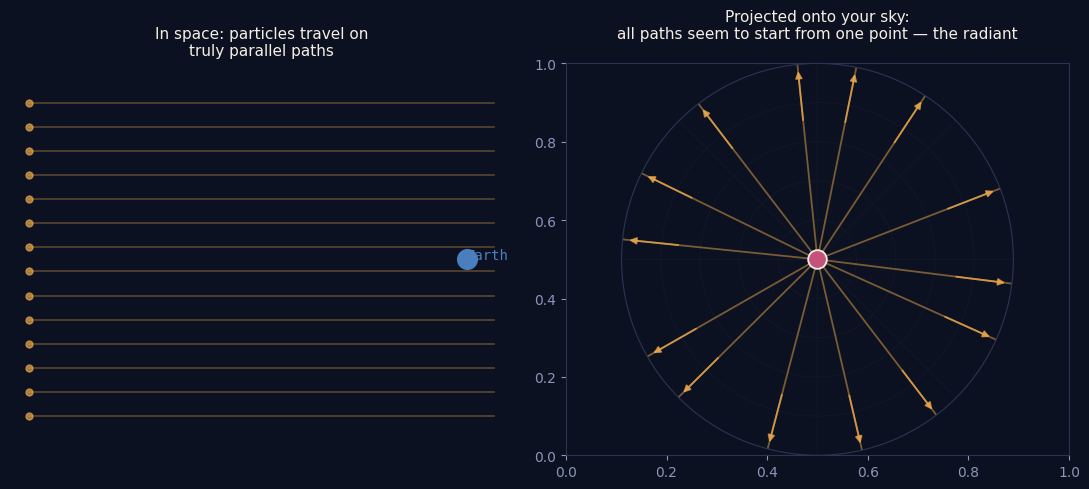

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

# Left: parallel paths in "space" (side view)
np.random.seed(7)
n_particles = 14
starts_y = np.linspace(-4, 4, n_particles)
for y0 in starts_y:
    ax1.plot([-6, 6], [y0, y0], color=AMBER, alpha=0.35, linewidth=1.2)
ax1.scatter(np.full(n_particles, -6), starts_y, color=AMBER, s=25, alpha=0.7)
ax1.annotate('Earth', (5.3, 0), color='#4A7FBF', fontsize=10, family='monospace')
ax1.scatter([5.3], [0], color='#4A7FBF', s=200, zorder=5)
ax1.set_xlim(-6.5, 6.5)
ax1.set_ylim(-5, 5)
ax1.set_title('In space: particles travel on\ntruly parallel paths', color=STAR, fontsize=11)
ax1.axis('off')

# Right: projected onto observer's sky -> converge to radiant
ax2 = plt.subplot(1, 2, 2, projection='polar')
n_rays = 14
rng = np.random.default_rng(3)
angles = np.linspace(0, 2*np.pi, n_rays, endpoint=False) + rng.uniform(-0.15, 0.15, n_rays)
for a in angles:
    ax2.plot([a, a], [0, 1], color=AMBER, alpha=0.5, linewidth=1.3)
    ax2.annotate('', xy=(a, 0.98), xytext=(a, 0.7),
                 arrowprops=dict(arrowstyle='-|>', color=AMBER, lw=1.3, alpha=0.8))
ax2.scatter([0], [0], color=PEAK, s=180, zorder=6, edgecolor=STAR, linewidth=1.3)
ax2.set_ylim(0, 1)
ax2.set_yticklabels([])
ax2.set_xticklabels([])
ax2.set_title('Projected onto your sky:\nall paths seem to start from one point — the radiant', color=STAR, fontsize=11, pad=18)
ax2.grid(alpha=0.15)

plt.tight_layout()
plt.savefig('radiant_perspective.png', dpi=130, facecolor=fig.get_facecolor())
plt.show()

## Summary

Three scales, one shower:

| Scale | Question answered | Visual |
|---|---|---|
| Solar system (millions of km) | Why does this happen in August at all? | Orbit intersection diagram |
| Trail cross-section (weeks) | Why does it peak on the 12th–13th specifically? | ZHR activity curve |
| Your sky (one night) | When and where do *you* look, from Akçay? | Radiant altitude curve (from the Astropy prototype) |
| Optics/perspective | Why does it look like it comes from one point at all? | Parallel-path projection |

This is the natural narrative spine for the blog post: zoom in from "why does this exist" all the way down to "here's your compass bearing for Tuesday night."
